In [27]:
# %%
import os
import pandas as pd
import numpy as np

DATA_DIR = "../data"

# --- Load model predictions ---
ann_preds_path   = os.path.join(DATA_DIR, "ANN_preds.csv")
log_preds_path   = os.path.join(DATA_DIR, "LOGREG_preds.csv")
gbm_preds_path   = os.path.join(DATA_DIR, "GBM_preds.csv")
rf_preds_path    = os.path.join(DATA_DIR, "RF_preds.csv")

# Uncomment these when you have the files:
# knn_preds_path   = os.path.join(DATA_DIR, "KNN_preds.csv")
# svm_preds_path   = os.path.join(DATA_DIR, "SVM_preds.csv")

ann_df  = pd.read_csv(ann_preds_path)
log_df  = pd.read_csv(log_preds_path)
gbm_df  = pd.read_csv(gbm_preds_path)
rf_df   = pd.read_csv(rf_preds_path)

# Uncomment when files exist:
# knn_df  = pd.read_csv(knn_preds_path)
# svm_df  = pd.read_csv(svm_preds_path)

print("ANN preds shape:", ann_df.shape)
print("Logistic preds shape:", log_df.shape)
print("GBM preds shape:", gbm_df.shape)
print("RF preds shape:", rf_df.shape)
# print("KNN preds shape:", knn_df.shape)
# print("SVM preds shape:", svm_df.shape)

# --- Load raw SPX close prices (1990–2018) ---
spx_path = os.path.join(DATA_DIR, "raw data", "sp500_1990_2018.csv")
spx_df   = pd.read_csv(spx_path)

print("SPX file columns:", list(spx_df.columns))
print("SPX rows:", len(spx_df))

# Expect something like ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
# but we only need the Close.

ANN preds shape: (3018, 6)
Logistic preds shape: (3018, 6)
GBM preds shape: (3018, 5)
RF preds shape: (3018, 5)
SPX file columns: ['Price', 'Close', 'High', 'Low', 'Open', 'Volume']
SPX rows: 7308


### 1. Build the price vector for the test period

We need N+1 closes to simulate N days of trading (you trade at price[t], then experience the move to price[t+1]).

In [41]:
import os
import pandas as pd
import numpy as np

DATA_DIR = "../data"

# --- Paths (using the correct filenames) ---
ann_preds_path = os.path.join(DATA_DIR, "ANN_preds.csv")
log_preds_path = os.path.join(DATA_DIR, "LOGREG_preds.csv")
gbm_preds_path = os.path.join(DATA_DIR, "GBM_preds.csv")
rf_preds_path  = os.path.join(DATA_DIR, "RF_preds.csv")

# Uncomment when available:
# knn_preds_path = os.path.join(DATA_DIR, "KNN_preds.csv")
# svm_preds_path = os.path.join(DATA_DIR, "SVM_preds.csv")

spx_path   = os.path.join(DATA_DIR, "raw data", "sp500_1990_2018.csv")
yq_path    = os.path.join(DATA_DIR, "y_test_quartile.csv")  # NEW: to recover test window

# --- Load predictions ---
ann_df = pd.read_csv(ann_preds_path)
log_df = pd.read_csv(log_preds_path)
gbm_df = pd.read_csv(gbm_preds_path)
rf_df  = pd.read_csv(rf_preds_path)

# Uncomment when available:
# knn_df = pd.read_csv(knn_preds_path)
# svm_df = pd.read_csv(svm_preds_path)

print("ANN preds shape:", ann_df.shape)
print("Logistic preds shape:", log_df.shape)
print("GBM preds shape:", gbm_df.shape)
print("RF preds shape:", rf_df.shape)
# print("KNN preds shape:", knn_df.shape)
# print("SVM preds shape:", svm_df.shape)

# --- Load SPX data ---
spx_df = pd.read_csv(spx_path)
spx_close = spx_df["Close"].reset_index(drop=True)

# --- Use y_test_quartile indices to define the test window (DATE-ALIGNED) ---
yq_df = pd.read_csv(yq_path)

# Original row indices used for the quartile test set
if "Unnamed: 0" in yq_df.columns:
    test_idx = yq_df["Unnamed: 0"].to_numpy()
else:
    test_idx = yq_df.index.to_numpy()

test_idx = np.sort(test_idx)
N = len(test_idx)

# Sanity check: number of labels vs number of preds
assert len(ann_df) == N, f"ANN preds length {len(ann_df)} != N labels {N}"

start_i = test_idx[0]
end_i   = test_idx[-1]
end_i_next = end_i + 1  # we need the 'next day' after the last label

# We need N+1 prices: from start_i ... end_i_next (inclusive)
prices_test = spx_close.iloc[start_i:end_i_next + 1].reset_index(drop=True)

print("N labels (test):", N)
print("prices_test length (should be N+1):", len(prices_test))
print("First 3 prices:\n", prices_test.head(3))
print("Last 3 prices:\n", prices_test.tail(3))

ANN preds shape: (3018, 6)
Logistic preds shape: (3018, 6)
GBM preds shape: (3018, 5)
RF preds shape: (3018, 5)
N labels (test): 3018
prices_test length (should be N+1): 3019
First 3 prices:
 0       1256.5400390625
1    1258.1700439453125
2    1254.4200439453125
Name: Close, dtype: object
Last 3 prices:
 3016    2681.469970703125
3017              2679.25
3018    2684.570068359375
Name: Close, dtype: object


### 2. Define a simple trading rule + simulator

We’ll implement this rule (consistent with what you said from the paper excerpt):
	•	Prediction -1 → be out of the market (all cash)
	•	Prediction 0 or 1 → be fully in the market (all in SPX)

Trading happens at the close of day t using pred[t] and price[t],
then you experience the move from price[t] → price[t+1].

In [44]:
def simulate_strategy(prices, signals, start_cash=100.0):
    """
    Trading simulator that follows the Table 5 Markov-style rule from the paper.

    prices  : 1D array-like of length N+1 (close prices)
    signals : 1D array-like of length N with values in {-1, 0, 1}
              (our multinomial classes for each daily return)
    start_cash : initial wealth, fully invested in stocks at the beginning.

    Returns:
        equity_curve: np.ndarray of length N+1
                      wealth at start + after each of the N daily moves.
    """
    prices = np.asarray(prices, dtype=float)
    signals = np.asarray(signals, dtype=int)

    N = len(signals)
    assert len(prices) == N + 1, "prices must have length N+1 for N signals"

    # Map {-1, 0, 1} -> {1, 2, 3} to match the paper's class labels
    def to_cls(s):
        if s == -1:
            return 1
        elif s == 0:
            return 2
        else:
            return 3

    # Start fully invested at the beginning of the period
    cash = 0.0
    shares = start_cash / prices[0]

    equity = np.zeros(N + 1, dtype=float)
    equity[0] = start_cash

    for t in range(N):
        price_t   = prices[t]
        price_next = prices[t + 1]

        if t == 0:
            # No previous forecast available yet; just ride the first day's move
            equity[t + 1] = cash + shares * price_next
            continue

        prev_cls = to_cls(signals[t - 1])  # R̂_t
        curr_cls = to_cls(signals[t])      # R̂_{t+1}

        # --- Table 5 decision logic ---
        # (prev_cls, curr_cls) -> action in {"buy", "sell", "stay_out", "hold"}
        if prev_cls == 1 and curr_cls == 1:
            action = "stay_out"          # ensure we are out of the market
        elif prev_cls in (2, 3) and curr_cls == 1:
            action = "sell"              # move to cash
        elif prev_cls == 1 and curr_cls in (2, 3):
            action = "buy"               # move into stocks
        else:  # prev_cls in {2,3} and curr_cls in {2,3}
            action = "hold"              # keep current position

        # Rebalance at the close of day t according to the action
        if action == "buy":
            if shares == 0.0 and cash > 0.0:
                shares = cash / price_t
                cash = 0.0
        elif action in ("sell", "stay_out"):
            if shares > 0.0:
                cash = shares * price_t
                shares = 0.0
        # "hold" -> no trade

        # After rebalancing, let the price move to next day
        equity[t + 1] = cash + shares * price_next

    return equity

### 3. Run the simulation for all experiments (ANN + LogReg)

Assuming both ann_df and log_df have columns exp1 … exp5:

In [45]:
# --- BASELINE: Buy & Hold (one position, never selling) ---
prices_arr = np.asarray(prices_test, dtype=float)
bh_final = 100.0 * (prices_arr[-1] / prices_arr[0])
bh_return = bh_final / 100.0 - 1.0

results = []

# Add baseline row FIRST
results.append({
    "Model": "BASELINE",
    "Experiment": "buy_hold",
    "Final Value": round(bh_final, 2),
    "Total Return (%)": round(bh_return * 100, 2),
})

# --- Run simulations for all models with preds ---
model_pred_pairs = [
    ("ANN",    ann_df),
    ("LOGREG", log_df),
    ("GBM",    gbm_df),
    ("RF",     rf_df),
    # Uncomment these when you have the files loaded:
    # ("KNN",    knn_df),
    # ("SVM",    svm_df),
]

for model_name, preds_df in model_pred_pairs:
    for exp_col in preds_df.columns:
        signals = preds_df[exp_col].astype(int).values
        equity_curve = simulate_strategy(prices_test, signals, start_cash=100.0)

        final_value = equity_curve[-1]
        total_return = final_value / 100.0 - 1.0

        results.append({
            "Model": model_name,
            "Experiment": exp_col,
            "Final Value": round(final_value, 2),
            "Total Return (%)": round(total_return * 100, 2),
        })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

   Model Experiment  Final Value  Total Return (%)
BASELINE   buy_hold       213.65            113.65
     ANN       exp1       189.66             89.66
     ANN       exp2       216.40            116.40
     ANN       exp3       121.54             21.54
     ANN       exp4       141.51             41.51
     ANN       exp5       124.85             24.85
     ANN       exp6       223.64            123.64
  LOGREG       exp1       221.41            121.41
  LOGREG       exp2       150.81             50.81
  LOGREG       exp3       148.45             48.45
  LOGREG       exp4       134.52             34.52
  LOGREG       exp5       135.08             35.08
  LOGREG       exp6       158.08             58.08
     GBM       exp1       163.17             63.17
     GBM       exp2       170.96             70.96
     GBM       exp3       179.31             79.31
     GBM       exp4        92.09             -7.91
     GBM       exp5       261.40            161.40
      RF       exp1       213.6

### DIAGNOSTICS



In [14]:
import numpy as np
import pandas as pd

# --- Daily returns from prices_test ---
price_arr = np.asarray(prices_test, dtype=float)
rets = (price_arr[1:] - price_arr[:-1]) / price_arr[:-1]   # length N

diag_rows = []

model_pred_pairs = [
    ("ANN",    ann_df),
    ("LOGREG", log_df),
    ("GBM",    gbm_df),
    ("RF",     rf_df),
    # Uncomment when available:
    # ("KNN",    knn_df),
    # ("SVM",    svm_df),
]

for model_name, preds_df in model_pred_pairs:
    for exp_col in preds_df.columns:
        sig = preds_df[exp_col].astype(int).values
        assert len(sig) == len(rets), f"Length mismatch for {model_name}-{exp_col}"

        unique, counts = np.unique(sig, return_counts=True)
        counts_dict = dict(zip(unique, counts))

        n_neg1 = counts_dict.get(-1, 0)
        n_0    = counts_dict.get(0, 0)
        n_1    = counts_dict.get(1, 0)
        n_total = len(sig)

        pct_neg1 = 100.0 * n_neg1 / n_total
        pct_in   = 100.0 * (n_total - n_neg1) / n_total   # time in market (0 or 1)
        pct_0    = 100.0 * n_0 / n_total
        pct_1    = 100.0 * n_1 / n_total

        # Correlation between signal and daily returns
        corr = np.corrcoef(sig, rets)[0, 1]

        diag_rows.append({
            "Model":        model_name,
            "Experiment":   exp_col,
            "n_-1":         n_neg1,
            "n_0":          n_0,
            "n_1":          n_1,
            "pct_-1":       round(pct_neg1, 2),
            "pct_in":       round(pct_in, 2),
            "pct_0":        round(pct_0, 2),
            "pct_1":        round(pct_1, 2),
            "corr(sig,ret)": round(corr, 4),
        })

diag_df = pd.DataFrame(diag_rows)
print(diag_df.to_string(index=False))

 Model Experiment  n_-1  n_0  n_1  pct_-1  pct_in  pct_0  pct_1  corr(sig,ret)
   ANN       exp1   114 1833 1071    3.78   96.22  60.74  35.49        -0.0255
   ANN       exp2    75 2450  493    2.49   97.51  81.18  16.34        -0.0069
   ANN       exp3   895 2087   36   29.66   70.34  69.15   1.19         0.0140
   ANN       exp4  3016    0    2   99.93    0.07   0.00   0.07         0.0092
   ANN       exp5  1200    0 1818   39.76   60.24   0.00  60.24        -0.0048
LOGREG       exp1     4 2851  163    0.13   99.87  94.47   5.40        -0.0069
LOGREG       exp2   591 2088  339   19.58   80.42  69.18  11.23         0.0077
LOGREG       exp3   837 1768  413   27.73   72.27  58.58  13.68        -0.0039
LOGREG       exp4  1945  337  736   64.45   35.55  11.17  24.39         0.0051
LOGREG       exp5  1770    0 1248   58.65   41.35   0.00  41.35         0.0030
   GBM       exp1   161 2716  141    5.33   94.67  89.99   4.67         0.0313
   GBM       exp2  1496  906  616   49.57   50.43  3

/Users/josephrichardson/opt/anaconda3/envs/clean_tf_env/lib/python3.9/site-packages/numpy/lib/function_base.py:2853: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/josephrichardson/opt/anaconda3/envs/clean_tf_env/lib/python3.9/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/josephrichardson/opt/anaconda3/envs/clean_tf_env/lib/python3.9/site-packages/numpy/lib/function_base.py:2853: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/josephrichardson/opt/anaconda3/envs/clean_tf_env/lib/python3.9/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


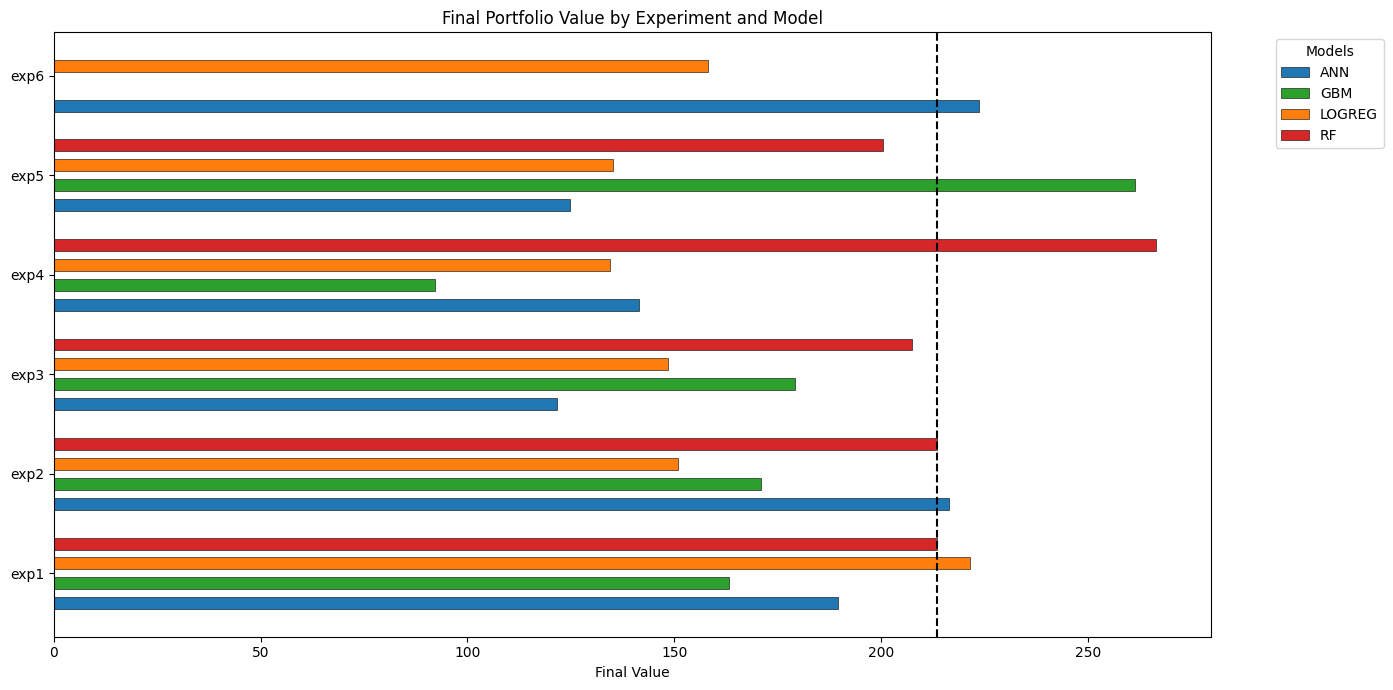

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================
#   Build plot data directly from results_df
# ============================================

# Drop baseline row for grouped bars
df = results_df[results_df["Model"] != "BASELINE"].copy()

# Extract baseline value automatically
baseline_val = float(results_df.loc[results_df["Model"] == "BASELINE", "Final Value"].iloc[0])

# Determine unique experiments & models from the DF
exps   = sorted(df["Experiment"].unique(), key=lambda x: int(x.replace("exp", "")))
models = sorted(df["Model"].unique())   # ANN, LOGREG, GBM, RF (and future KNN/SVM)

# --- Six-color palette (future-proof) ---
colors = {
    "ANN":    "#1f77b4",  # blue
    "LOGREG": "#ff7f0e",  # orange
    "GBM":    "#2ca02c",  # green
    "RF":     "#d62728",  # deep red
    "KNN":    "#9467bd",  # purple
    "SVM":    "#8c564b",  # brown
}

# Layout settings
fig, ax = plt.subplots(figsize=(14, 7))

group_height = 1.0
bar_height   = 0.12
offsets = np.linspace(-0.3, 0.3, len(models))

# ==========================
#   Draw grouped bar chart
# ==========================
for i, exp in enumerate(exps):
    base_y = i * group_height
    for j, model in enumerate(models):
        sub = df[(df["Model"] == model) & (df["Experiment"] == exp)]
        if sub.empty:
            continue  # model not available yet (e.g., KNN/SVM)
        val = sub["Final Value"].iloc[0]
        y = base_y + offsets[j]

        ax.barh(
            y, val,
            height=bar_height,
            color=colors.get(model, "gray"),
            label=model if i == 0 else None,
            edgecolor="black",
            linewidth=0.4
        )

# Baseline vertical dashed line
ax.axvline(baseline_val, color="black", linestyle="--", linewidth=1.5)

# Tick labels
ax.set_yticks([i * group_height for i in range(len(exps))])
ax.set_yticklabels(exps)

ax.set_xlabel("Final Value")
ax.set_title("Final Portfolio Value by Experiment and Model")

# Legend outside plot
ax.legend(title="Models", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [36]:
import os
import pandas as pd
import numpy as np

# --- Load true test labels for the quartile scheme (paper's 25/75 thresholds) ---
y_quart_path = os.path.join(DATA_DIR, "y_test_quartile.csv")
yq_df = pd.read_csv(y_quart_path)

# Drop index column if present and pull the single label column
if "Unnamed: 0" in yq_df.columns:
    yq_df = yq_df.drop(columns=["Unnamed: 0"])
if yq_df.shape[1] != 1:
    raise ValueError(f"Expected 1 label column in y_test_quartile.csv, got {yq_df.shape[1]}")

y_true_quart = yq_df.iloc[:, 0].astype(int).to_numpy()

print("Oracle labels length:", len(y_true_quart))
print("prices_test length:", len(prices_test))
assert len(prices_test) == len(y_true_quart) + 1, "prices_test must have N+1 entries for N labels"

# --- Run oracle simulation (perfect information) ---
equity_oracle = simulate_strategy(prices_test, y_true_quart, start_cash=100.0)
oracle_final = equity_oracle[-1]
oracle_ret   = oracle_final / 100.0 - 1.0

print("\n=== Oracle (true labels, quartile scheme) ===")
print(f"Final Value:      {oracle_final:.2f}")
print(f"Total Return (%): {oracle_ret * 100:.2f}")

Oracle labels length: 3018
prices_test length: 3019

=== Oracle (true labels, quartile scheme) ===
Final Value:      53.73
Total Return (%): -46.27


In [48]:
# --- Sanity check: actual buy & hold return from prices_test ---

# Handle both Series and ndarray
prices_arr = np.asarray(prices_test, dtype=float)

p0 = float(prices_arr[0])
pT = float(prices_arr[-1])

pct_return = (pT / p0 - 1.0) * 100
final_value = 100.0 * (pT / p0)

print("=== Buy & Hold Sanity Check ===")
print(f"Start price: {p0:.4f}")
print(f"End price:   {pT:.4f}")
print(f"Return (%):  {pct_return:.2f}")
print(f"$100 → ${final_value:.2f}")

=== Buy & Hold Sanity Check ===
Start price: 1256.5400
End price:   2684.5701
Return (%):  113.65
$100 → $213.65
